# Flight Price Prediction

This project predicts airline ticket prices using machine learning techniques.

Dataset features include airline, source, destination, journey date, departure time, arrival time, duration, and number of stops.

Models Used:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel("Data_Train.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df.shape

(10683, 11)

In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df=df.dropna()

##### ML models cannot directly use strings so we have converted it to numerical value.

In [10]:
df["Journey_Day"]=pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.day

In [11]:
df["Journey_Month"]=pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.month

In [12]:
df.drop("Date_of_Journey",axis=1,inplace=True)

In [13]:
df["Dep_Hour"]=pd.to_datetime(
    df["Dep_Time"],
    format="%H:%M"
).dt.hour

In [14]:
df["Dep_Min"]=pd.to_datetime(
    df["Dep_Time"],
    format="%H:%M"
).dt.minute

In [15]:
df.drop("Dep_Time",axis=1,inplace=True)

In [16]:
df["Arrival_Hour"] =pd.to_datetime(
    df["Arrival_Time"]
).dt.hour

df["Arrival_Min"]=pd.to_datetime(
    df["Arrival_Time"]
).dt.minute

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22004\537748821.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Hour"] =pd.to_datetime(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22004\537748821.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Min"]=pd.to_datetime(


In [17]:
df.drop("Arrival_Time", axis=1, inplace=True)

In [18]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [19]:
hours = []
mins = []

for i in df["Duration"]:

    if len(i.split()) == 2:
        h = int(i.split()[0][:-1])
        m = int(i.split()[1][:-1])

    elif 'h' in i:
        h = int(i[:-1])
        m = 0

    else:
        h = 0
        m = int(i[:-1])

    hours.append(h)
    mins.append(m)

In [20]:
df["Duration_Hours"]=hours
df["Duration_Mins"]=mins
df.drop("Duration", axis=1, inplace=True)

In [21]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


### Exploratory Data Analysis (EDA)

In [22]:
for col in ["Airline","Source","Destination","Route","Total_Stops","Additional_Info"]:
    print(col)
    print(df[col].nunique())

Airline
12
Source
5
Destination
6
Route
128
Total_Stops
5
Additional_Info
10


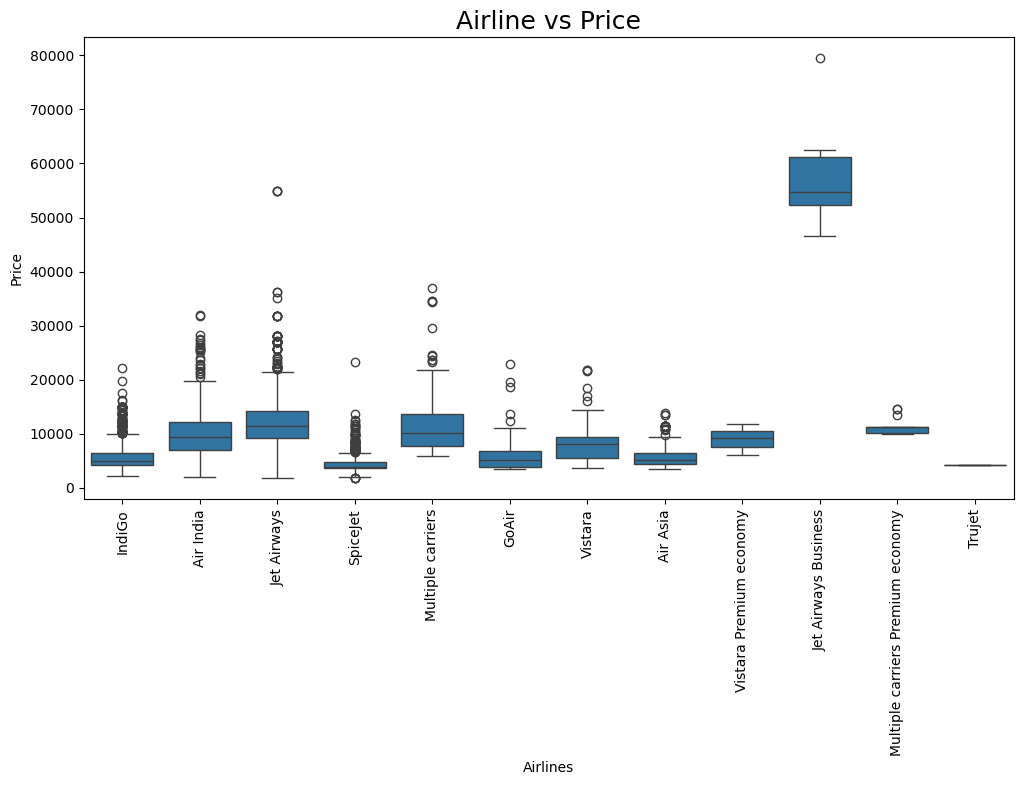

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Price", fontsize=18)
plt.xlabel("Airlines")
plt.ylabel("Price")
plt.show()

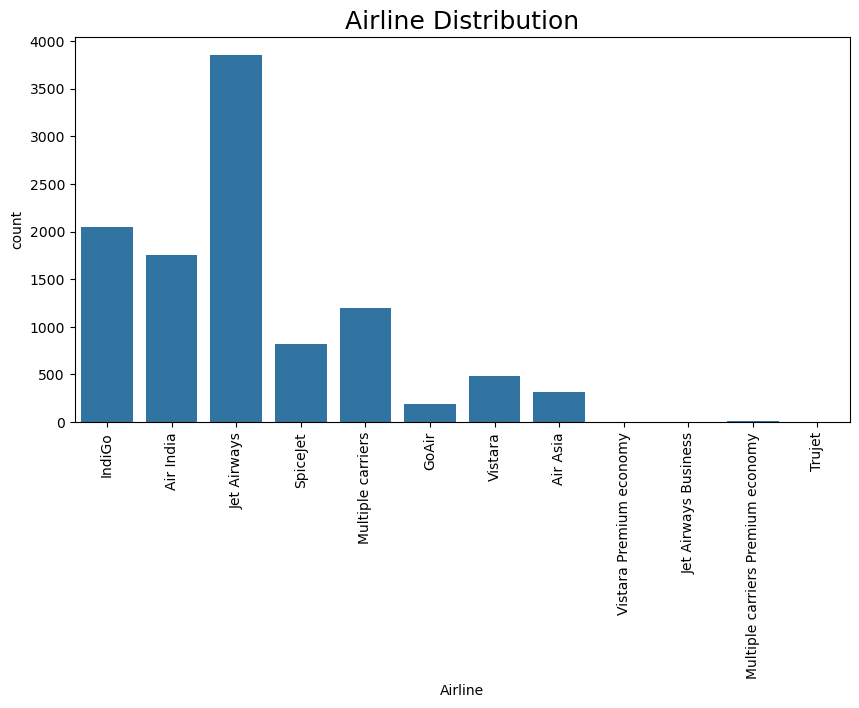

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x="Airline", data=df)
plt.xticks(rotation=90)
plt.title("Airline Distribution", fontsize=18)
plt.show()

* Some airlines have a higher count which leads to dataset imbalance
* It can influence model learning part.

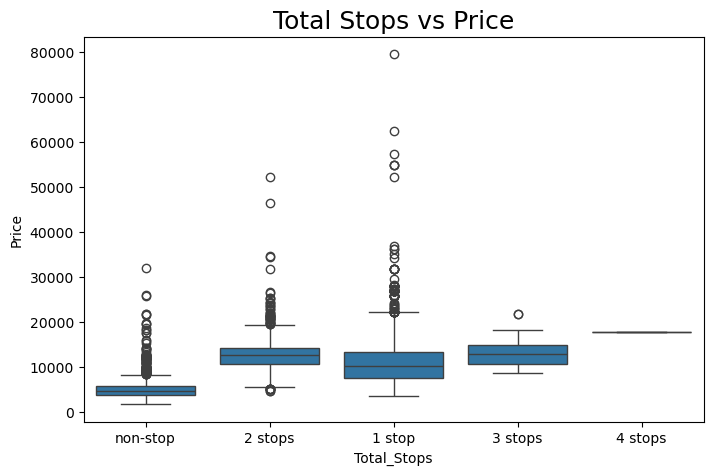

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.title("Total Stops vs Price", fontsize=18)
plt.show()

* Flights with more stops tends to have higher price

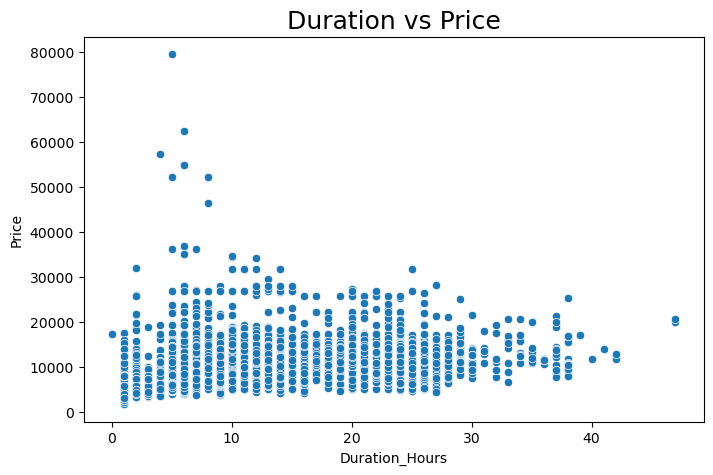

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Duration_Hours",
    y="Price",
    data=df
)
plt.title("Duration vs Price", fontsize=18)
plt.show()

* There isn't a linear relationship between duration and price
* There is a price drop for extremely long duration

In [27]:
df.drop("Route", axis=1, inplace=True)

### Encoding Categorical Variables

Machine learning models require numerical inputs.

1. Total Stops -> Ordinal Encoding
2. Airline, Source, Destination, Additional Info -> One-Hot Encoding

In [28]:
df["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [29]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [30]:
df = pd.get_dummies(
    df,
    columns=[
        "Airline",
        "Source",
        "Destination",
        "Additional_Info"
    ],
    drop_first=True
)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Total_Stops                                   10682 non-null  int64
 1   Price                                         10682 non-null  int64
 2   Journey_Day                                   10682 non-null  int32
 3   Journey_Month                                 10682 non-null  int32
 4   Dep_Hour                                      10682 non-null  int32
 5   Dep_Min                                       10682 non-null  int32
 6   Arrival_Hour                                  10682 non-null  int32
 7   Arrival_Min                                   10682 non-null  int32
 8   Duration_Hours                                10682 non-null  int64
 9   Duration_Mins                                 10682 non-null  int64
 10  Airline_Air Ind

## Model Building

In [32]:
y=df["Price"]
X=df.drop("Price", axis=1)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

In [35]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
lr_pred=lr.predict(X_test)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
print("MAE:", mean_absolute_error(y_test,lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

MAE: 1777.7057892437479
RMSE: 2588.453754933363
R2: 0.6892646628549659


The model explains about 68.9% of the variation in flight prices.
High RMSE suggests that the relationship between flight attributes and ticket prices may be non-linear.

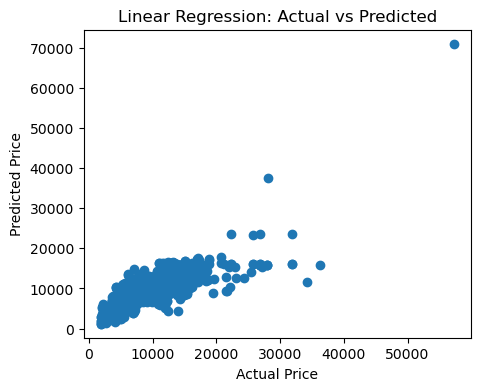

In [38]:
plt.figure(figsize=(5,4))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

### Decision Tree

In [39]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

In [40]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [41]:
dt_pred = dt.predict(X_test)

In [42]:
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2:", r2_score(y_test, dt_pred))

MAE: 675.5570893776322
RMSE: 1806.1520039193529
R2: 0.8487071449856854


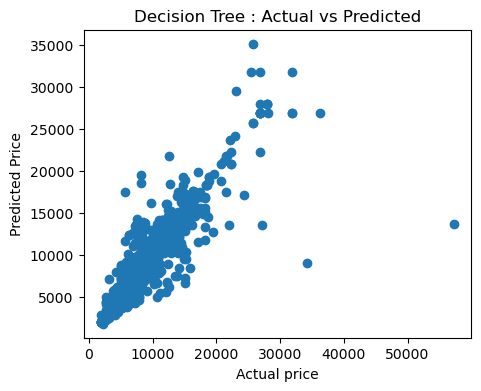

In [43]:
plt.figure(figsize=(5,4))
plt.scatter(y_test,dt_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree : Actual vs Predicted")
plt.show()    

### Random Forest

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [45]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
rf_pred = rf.predict(X_test)

In [47]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

MAE: 645.5658896632276
RMSE: 1622.4739559041657
R2: 0.8779141609681493


Random Forest explains about 87.8% of the variance in flight prices

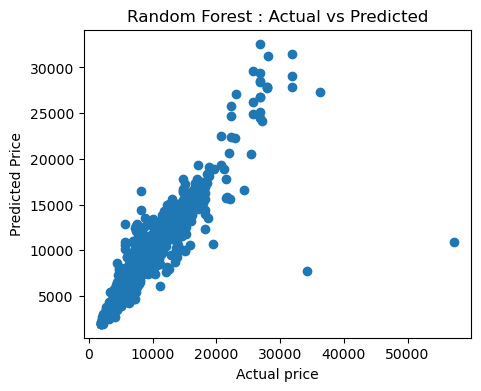

In [48]:
plt.figure(figsize=(5,4))
plt.scatter(y_test,rf_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted Price")
plt.title("Random Forest : Actual vs Predicted")
plt.show()    

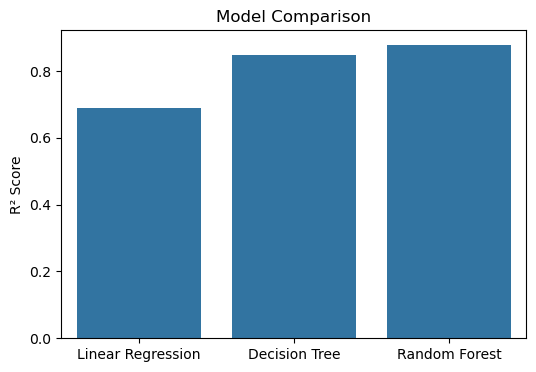

In [49]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]
r2_scores = [0.689, 0.849, 0.878]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=r2_scores)

plt.ylabel("R² Score")
plt.title("Model Comparison")

plt.show()

### Feature Importance

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance.head(10))

                                        Feature  Importance
7                                Duration_Hours    0.429326
1                                   Journey_Day    0.095831
33  Additional_Info_In-flight meal not included    0.076479
12                          Airline_Jet Airways    0.062194
13                 Airline_Jet Airways Business    0.059197
2                                 Journey_Month    0.046993
0                                   Total_Stops    0.032102
5                                  Arrival_Hour    0.028921
28                        Destination_New Delhi    0.025646
3                                      Dep_Hour    0.023802


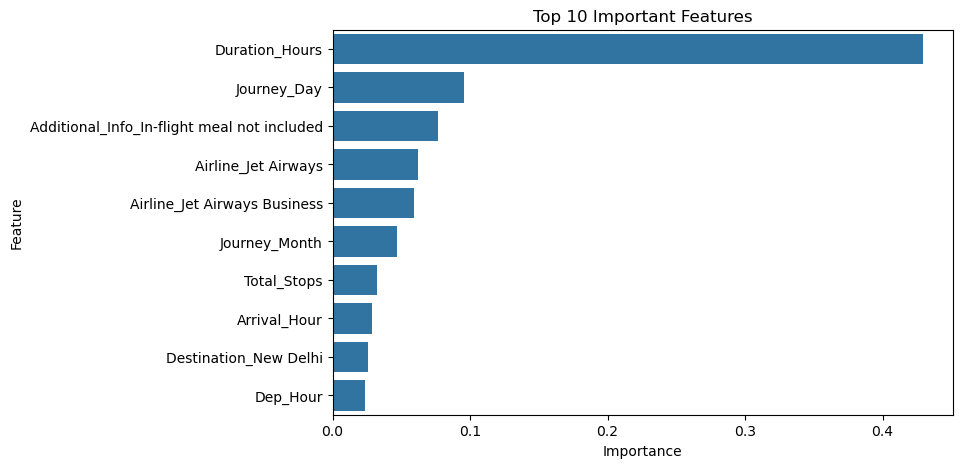

In [51]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

In [52]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators": [50,100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [53]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

In [54]:
grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [55]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.854831383514756


In [56]:
print(grid.score(X_test, y_test))

0.8784832001214083


In [57]:
import joblib

joblib.dump(rf, "flight_rf_model.pkl")

['flight_rf_model.pkl']

In [58]:
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']